In [27]:
!pip install yfinance 

Defaulting to user installation because normal site-packages is not writeable


In [28]:
# import libraires 

import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf 

======== complete stock analyzer ===


Enter the stock symbol (or Q to Quit): nvda


[*********************100%***********************]  1 of 1 completed


 Company :NVIDIA Corporation
 Current Price: 210.96



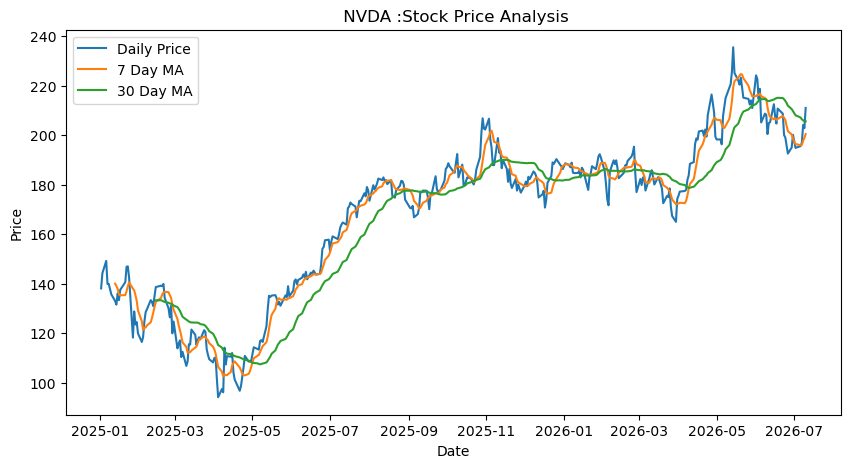

In [ ]:
print("======== complete stock analyzer ===")

while True:

    symbol = input("Enter the stock symbol (or Q to Quit):").upper()

    if symbol =="Q":
        print("Existing Program...")
        break 

    try:
        stock =yf.Ticker(symbol)
        info = stock.info

        name= info.get("longName","N/A")
        price = info.get("currentPrice")
        prev_close = info.get("previousClose")
        currency = info.get("currency","USD")

        print("\n ==============")
        print(f" Company :{name}")
        print(f" Current Price: {price}")
        print("\n==================")

        # Download the historical data 

        df = yf.download(symbol,start= "2025-01-01",end="2026-07-12", interval="1d")


        # Moving average 

        df["7_day_MA"] = df["Close"].rolling(window=7).mean()
        df["30_day_MA"]= df["Close"].rolling(window=30).mean()

        # plot the graph 

        plt.figure(figsize=(10,5))
        plt.plot(df["Close"],label="Daily Price")
        plt.plot(df["7_day_MA"],label="7 Day MA")
        plt.plot(df["30_day_MA"],label = "30 Day MA")
        plt.title(f" {symbol} :Stock Price Analysis")
        plt.xlabel("Date")
        plt.ylabel("Price")
        plt.legend()
        plt.show()
    
    except Exception as e:
        print("Invalid Symbol or Network error\n")